In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import copy
from utilities import *

In [32]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [33]:
result_dir = '../results/data/'

data = pd.read_pickle(result_dir + 'combined_raw_dy.pkl')

In [34]:
hu = read_sas('../data/Apply_MI_Zheng_2023_01/hu.sas7bdat')
data_copy_nohu = data[~data['SCCRIP_ID'].isin(hu['SCCRIP_ID'].unique())]

In [35]:
ctxn = read_sas('../data/Apply_MI_Zheng_2023_01/ctxn.sas7bdat')

data_nohu_noctxn = data_copy_nohu[~data_copy_nohu['SCCRIP_ID'].isin(ctxn['SCCRIP_ID'].unique())]

In [36]:
blood_trans = read_sas('../data/Apply_MI_Zheng_2023_01/bloodtrans_final.sas7bdat')

data_notrans = data_nohu_noctxn[~data_nohu_noctxn['SCCRIP_ID'].isin(blood_trans['SCCRIP_ID'].unique())]

In [37]:
other = read_sas('../data/Apply_MI_Zheng_2023_01/othertreatment_summary.sas7bdat')
other = other[other['Other_treat'] != 1]
data_noall = data_notrans[~data_notrans['SCCRIP_ID'].isin(other['SCCRIP_ID'].unique())]

In [38]:
data_treat = data[~data['SCCRIP_ID'].isin(data_noall['SCCRIP_ID'].unique())]

In [39]:
g = data_noall.groupby('SCCRIP_ID')
print(f"total no treatment IDs {len(g.groups.keys())}")
import matplotlib as mpl

# Set all font sizes to 18
mpl.rcParams.update({'font.size': 24})
for k in g.groups.keys():
    df = g.get_group(k)
    
    # df = df[df['Ages'] >= 2.5]
    df = df.sort_values(by="Ages")
    if len(df) > 5:
        plt.figure(figsize=(10, 6))
        plt.plot(df['Ages'], df['Hgb_F_hemoglobineid'], 'o-', label='HbF', linewidth=5)
        # plt.axvline(3, color='black', linestyle='--', linewidth=1, label='Age = 3')
        # plt.xlim([2.9, max(list(df['Ages']))])
        plt.xlabel('Age')
        plt.ylabel('HbF%')
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.savefig('../results/figures/summary/hbf_pure_patients/' + k + '.pdf')

        plt.close() 

total no treatment IDs 376


In [40]:
no_treat = data_noall['SCCRIP_ID'].unique()
treat = data_treat['SCCRIP_ID'].unique()

df_ = data[['SCCRIP_ID', 'Ages', 'Hgb_F_hemoglobineid']]

df_list = []
g = df_.groupby('SCCRIP_ID')
for k in g.groups.keys():
    df = g.get_group(k)
    df = df.sort_values(by="Ages")
    
    if len(df) > 5:
        df['diff'] = df['Hgb_F_hemoglobineid'].diff().fillna(99999)
        df_list.append(copy.deepcopy(df))

In [41]:
new_data = pd.concat(df_list, ignore_index=True)

new_data = new_data[new_data['diff'] != 99999]

new_data['abs_diff'] = new_data['diff'].abs()

new_data['treat'] = np.where(new_data['SCCRIP_ID'].isin(no_treat), 'No treatment', 'Treatment')

In [42]:
bins = [0, 2, 6, 12, 18, 24, np.inf]  # np.inf represents infinity
labels = ['infant', 'toddler', 'school_age', 'teenager', 'young_adult', 'adult']

# bins = [0, 2,18, np.inf]  # np.inf represents infinity
# labels = ['<2', '2-18', '>18']

# Create a new column 'range_category' by binning 'value'
new_data['chort'] = pd.cut(new_data['Ages'], bins=bins, right=False, labels=labels)

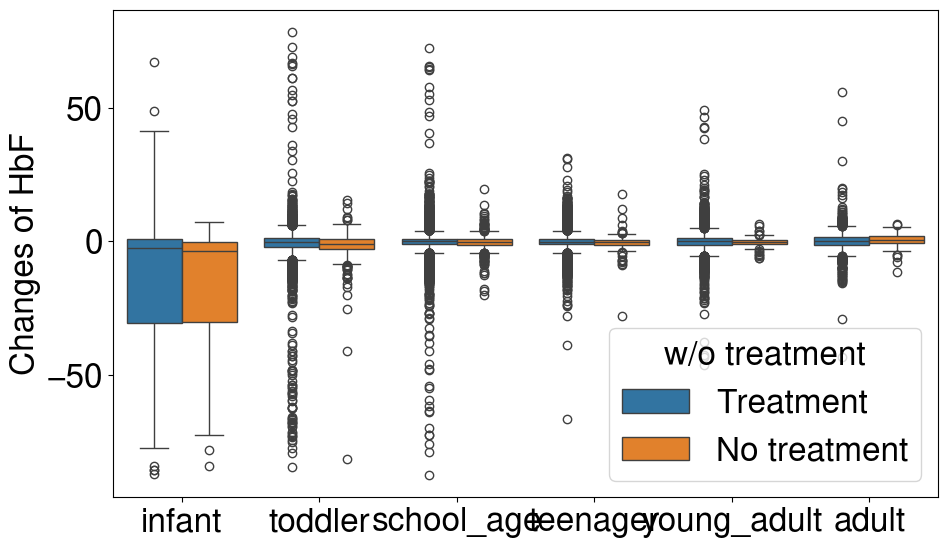

In [43]:
# Create the boxplot using seaborn
plt.figure(figsize=(10, 6)) 
sns.boxplot(data=new_data, x='chort', y='diff', hue='treat' )

# Customize the plot
plt.title("")
plt.xlabel("")
plt.ylabel("Changes of HbF")
plt.legend(title='w/o treatment')
plt.tight_layout()
# Display the plot
plt.savefig('../results/figures/summary/raw_hbf_changed.pdf')
plt.show()

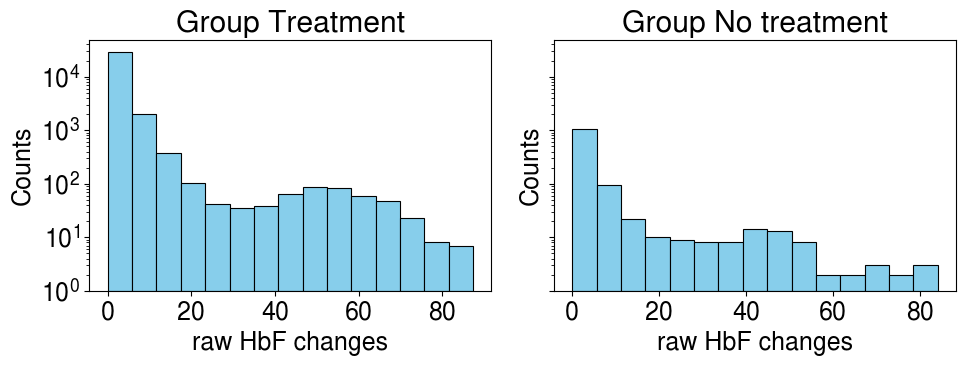

In [51]:
mpl.rcParams.update({'font.size': 18})
import numpy as np
import matplotlib.pyplot as plt

groups = new_data['treat'].unique()
num_groups = len(groups)

fig, axes = plt.subplots(1, num_groups, figsize=(5 * num_groups, 4), sharey=True)
if num_groups == 1:
    axes = [axes]

bins = 15
baseline = 1  # critical: bars start at 1, never at 0 (log-safe)

for ax, group in zip(axes, groups):
    subset = new_data.loc[new_data['treat'] == group, 'abs_diff'].dropna().to_numpy()

    counts, edges = np.histogram(subset, bins=bins)
    widths = np.diff(edges)

    # draw histogram as bars with a positive baseline
    ax.bar(
        edges[:-1],
        counts,
        width=widths,
        align='edge',
        bottom=baseline,
        edgecolor='black',
        color='skyblue',
        linewidth=0.8
    )

    ax.set_title(f'Group {group}')
    ax.set_xlabel('raw HbF changes')
    ax.set_ylabel('Counts')
    ax.set_yscale('log')
    ax.set_ylim(bottom=baseline)  # keep baseline consistent

plt.tight_layout()
plt.savefig('../results/figures/summary/raw_hbf_hist.pdf', bbox_inches='tight', transparent=False)
